In [1]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))

%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.adaline_sgd import AdalineSGD
from src.utils import plot_decision_regions

DATA_DIR = project_root / 'data'

# Adaline — стохастический градиентный спуск (AdalineSGD)

## Тестирование на датасете ирисов

### Загрузка и предобработка данных

In [2]:
df = pd.read_csv(DATA_DIR / 'iris.data', header=None, encoding='utf-8')
y = np.where(df.iloc[0:100, 4].values == 'Iris-setosa', 0, 1)
X = df.iloc[0:100, [0, 2]].values
df.head()

,0,1,2,3,4
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


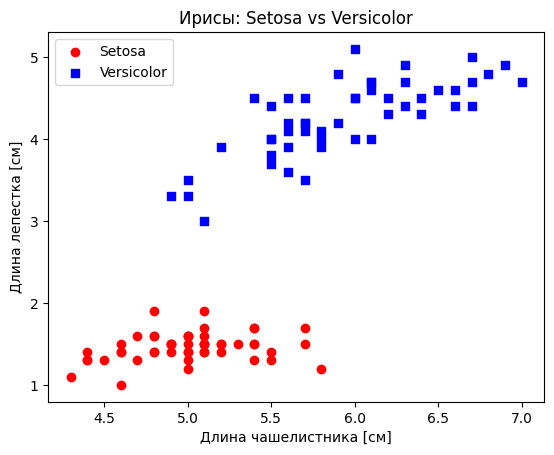

In [3]:
plt.scatter(X[:50, 0], X[:50, 1], color='red', marker='o', label='Setosa')
plt.scatter(X[50:100, 0], X[50:100, 1], color='blue', marker='s', label='Versicolor')
plt.xlabel('Длина чашелистника [см]')
plt.ylabel('Длина лепестка [см]')
plt.legend(loc='upper left')
plt.title('Ирисы: Setosa vs Versicolor')
plt.show()

### Без стандартизации

Точность (без станд.): 100.00%


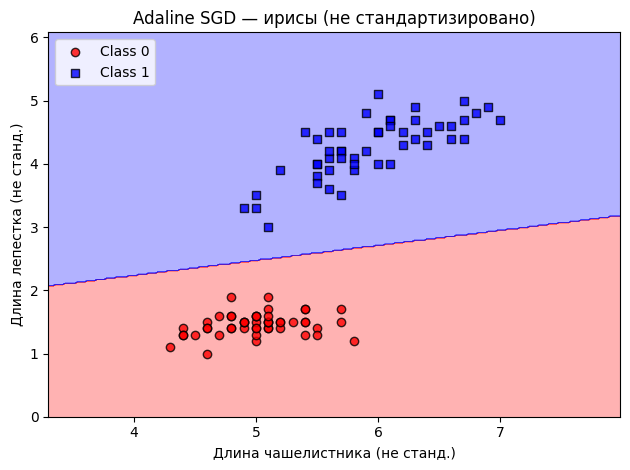

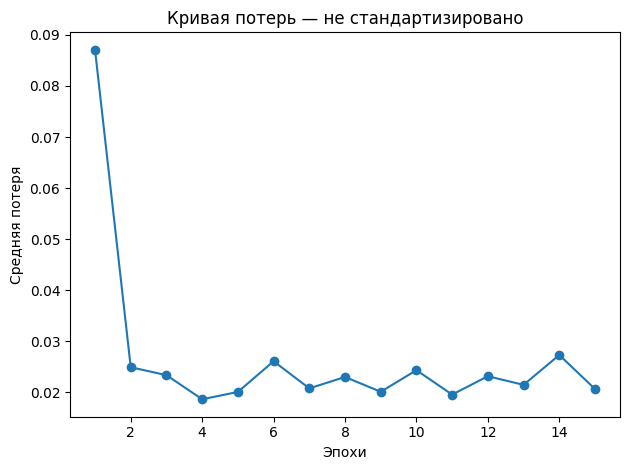

In [4]:
ada_sgd = AdalineSGD(n_iter=15, eta=0.01, random_state=1)
ada_sgd.fit(X, y)

accuracy = (ada_sgd.predict(X) == y).mean()
print(f'Точность (без станд.): {accuracy:.2%}')

plot_decision_regions(X, y, classifier=ada_sgd)
plt.title('Adaline SGD — ирисы (не стандартизировано)')
plt.xlabel('Длина чашелистника (не станд.)')
plt.ylabel('Длина лепестка (не станд.)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

plt.plot(range(1, len(ada_sgd.losses_) + 1), ada_sgd.losses_, marker='o')
plt.xlabel('Эпохи')
plt.ylabel('Средняя потеря')
plt.title('Кривая потерь — не стандартизировано')
plt.tight_layout()
plt.show()

### Со стандартизацией

Точность (со станд.): 100.00%


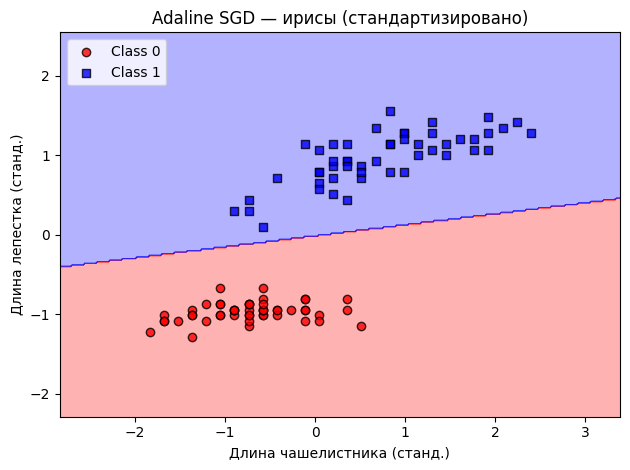

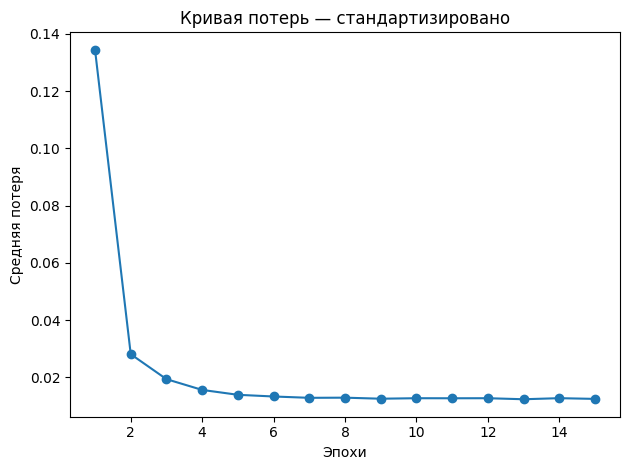

Вывод: перед градиентными методами всегда стандартизируйте признаки!


In [5]:
X_std = np.copy(X)
X_std[:, 0] = (X[:, 0] - X[:, 0].mean()) / X[:, 0].std()
X_std[:, 1] = (X[:, 1] - X[:, 1].mean()) / X[:, 1].std()

ada_sgd = AdalineSGD(n_iter=15, eta=0.01, random_state=1)
ada_sgd.fit(X_std, y)

accuracy = (ada_sgd.predict(X_std) == y).mean()
print(f'Точность (со станд.): {accuracy:.2%}')

plot_decision_regions(X_std, y, classifier=ada_sgd)
plt.title('Adaline SGD — ирисы (стандартизировано)')
plt.xlabel('Длина чашелистника (станд.)')
plt.ylabel('Длина лепестка (станд.)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

plt.plot(range(1, len(ada_sgd.losses_) + 1), ada_sgd.losses_, marker='o')
plt.xlabel('Эпохи')
plt.ylabel('Средняя потеря')
plt.title('Кривая потерь — стандартизировано')
plt.tight_layout()
plt.show()

print('Вывод: перед градиентными методами всегда стандартизируйте признаки!')

## Тестирование на датасете пингвинов Палмера

### Загрузка и предобработка данных

In [6]:
df_p = pd.read_csv(DATA_DIR / 'penguins.data').dropna()
df_p = df_p[(df_p['species'] == 'Adelie') | (df_p['species'] == 'Chinstrap')]

y_p = np.where(df_p['species'].values == 'Adelie', 0, 1)
X_p = df_p[['bill_length_mm', 'bill_depth_mm']].values

df_p.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


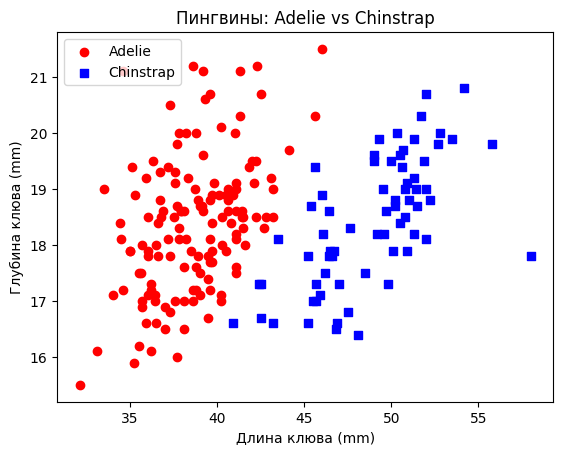

In [7]:
plt.scatter(X_p[y_p == 0, 0], X_p[y_p == 0, 1], color='red', marker='o', label='Adelie')
plt.scatter(X_p[y_p == 1, 0], X_p[y_p == 1, 1], color='blue', marker='s', label='Chinstrap')
plt.xlabel('Длина клюва (mm)')
plt.ylabel('Глубина клюва (mm)')
plt.legend(loc='upper left')
plt.title('Пингвины: Adelie vs Chinstrap')
plt.show()

### Стандартизация + обучение

Точность на пингвинах: 98.08%


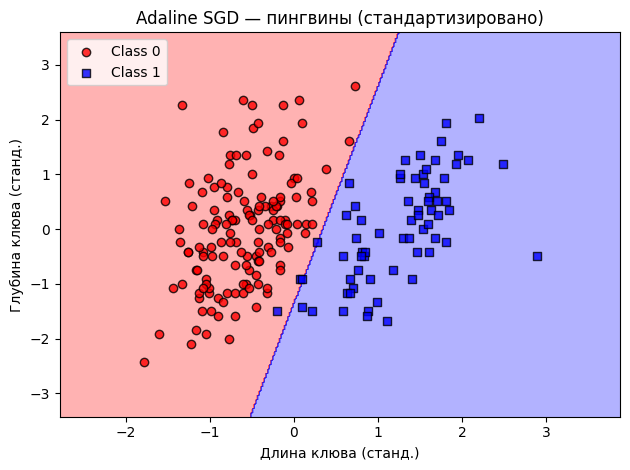

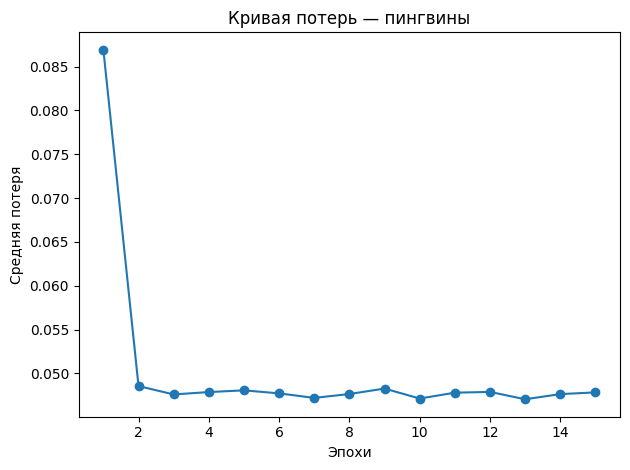

In [8]:
X_p_std = np.copy(X_p)
X_p_std[:, 0] = (X_p[:, 0] - X_p[:, 0].mean()) / X_p[:, 0].std()
X_p_std[:, 1] = (X_p[:, 1] - X_p[:, 1].mean()) / X_p[:, 1].std()

ada_sgd_p = AdalineSGD(n_iter=15, eta=0.01, random_state=1)
ada_sgd_p.fit(X_p_std, y_p)

accuracy = (ada_sgd_p.predict(X_p_std) == y_p).mean()
print(f'Точность на пингвинах: {accuracy:.2%}')

plot_decision_regions(X_p_std, y_p, classifier=ada_sgd_p)
plt.title('Adaline SGD — пингвины (стандартизировано)')
plt.xlabel('Длина клюва (станд.)')
plt.ylabel('Глубина клюва (станд.)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

plt.plot(range(1, len(ada_sgd_p.losses_) + 1), ada_sgd_p.losses_, marker='o')
plt.xlabel('Эпохи')
plt.ylabel('Средняя потеря')
plt.title('Кривая потерь — пингвины')
plt.tight_layout()
plt.show()

### Примеры предсказаний

In [9]:
species_names = {0: 'Adelie', 1: 'Chinstrap'}
sample_idx = [0, 1, 2, -3, -2, -1]
y_pred = ada_sgd_p.predict(X_p_std[sample_idx])
y_true = y_p[sample_idx]

print(f'{"Истина":<12} {"Предсказание":<14} Верно?')
print('-' * 36)
for t, p in zip(y_true, y_pred):
    mark = 'да' if t == p else 'нет'
    print(f'{species_names[t]:<12} {species_names[p]:<14} {mark}')

Истина       Предсказание   Верно?
------------------------------------
Adelie       Adelie         да
Adelie       Adelie         да
Adelie       Adelie         да
Chinstrap    Chinstrap      да
Chinstrap    Chinstrap      да
Chinstrap    Chinstrap      да
